# 로지스틱 회귀 - 타이타닉 생존 여부 예측

In [14]:
# 라이브러리 임포트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

%matplotlib inline

## 1. 데이터 로드 및 탐색

In [15]:
# 데이터 로드
df = pd.read_csv(r'pandas/data/titanic_train.csv')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embark_town
0,0,3,male,22.0,1,0,7.2500,Southampton
1,1,1,female,38.0,1,0,71.2833,Cherbourg
2,1,3,female,26.0,0,0,7.9250,Southampton
3,1,1,female,35.0,1,0,53.1000,Southampton
4,0,3,male,35.0,0,0,8.0500,Southampton


In [16]:
# 데이터 기본 정보 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embark_town  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [17]:
# 결측치 확인
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embark_town      2
dtype: int64

In [18]:
# 종속변수(survived) 분포 확인
df['survived'].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

## 2. 데이터 전처리

In [19]:
# 결측치 처리
# age: 중앙값으로 대치 (177개 결측)
df['age'] = df['age'].fillna(df['age'].median())

# embark_town: 최빈값으로 대치 (2개 결측)
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])

# 결측치 처리 확인
df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embark_town    0
dtype: int64

In [20]:
# 범주형 변수 원핫인코딩 (sex, embark_town)
df = pd.get_dummies(df, columns=['sex', 'embark_town'], drop_first=True, dtype='i1')
df.head()

,survived,pclass,age,sibsp,parch,fare,sex_male,embark_town_Queenstown,embark_town_Southampton
0,0,3,22.0,1,0,7.2500,1,0,1
1,1,1,38.0,1,0,71.2833,0,0,0
2,1,3,26.0,0,0,7.9250,0,0,1
3,1,1,35.0,1,0,53.1000,0,0,1
4,0,3,35.0,0,0,8.0500,1,0,1


## 3. 학습/테스트 분리 및 스케일링

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 독립변수(X)와 종속변수(y) 분리
X = df.drop(columns=['survived'])
y = df['survived']

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

# 학습/테스트 분리 (8:2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

X shape: (891, 8)
y shape: (891,)
Train: (712, 8), Test: (179, 8)


In [22]:
# 스케일링 (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # train으로 fit + transform
X_test_scaled = scaler.transform(X_test)         # test는 transform만

print(f'Train 평균: {X_train_scaled.mean():.4f}, 표준편차: {X_train_scaled.std():.4f}')

Train 평균: 0.0000, 표준편차: 1.0000


## 4. 로지스틱 회귀 모델 학습 및 예측

### 시그모이드 함수란?

로지스틱 회귀는 내부적으로 **시그모이드(Sigmoid) 함수**를 사용하여 예측값을 0~1 사이의 확률로 변환합니다.

---

### 왜 시그모이드가 필요한가?

선형회귀는 결과가 `-∞ ~ +∞` 어디든 나올 수 있습니다.  
하지만 생존 **확률**은 반드시 **0~1 사이**여야 합니다.

> 시그모이드(S자 곡선)가 어떤 숫자든 0~1 사이로 압축해줍니다.

```
z (선형결합 결과)    →    σ(z) 확률
      -10          →     0.00005  (거의 확실히 사망)
       -2          →     0.12     (사망 가능성 높음)
        0          →     0.50     (반반, 경계선)
       +2          →     0.88     (생존 가능성 높음)
      +10          →     0.99995  (거의 확실히 생존)
```

---

### 공식

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

- **e** : 자연상수 ≈ 2.718
- **z가 크면** e^(-z) → 0 → σ(z) → 1 (생존)
- **z가 작으면** e^(-z) → ∞ → σ(z) → 0 (사망)

---

### 가중치(w)와 intercept는 어떻게 결정되는가?

> **사람이 정하는 것이 아닙니다. `fit()` 이 자동으로 찾아줍니다.**

#### 학습(fit)이 하는 일

```
① 처음에 w, intercept를 임의의 값으로 시작
② 전체 훈련 데이터에 대해 예측 → 실제 정답과 비교 → 오차(Loss) 계산
③ 오차가 줄어드는 방향으로 w, intercept 값을 조금씩 수정
④ ②~③을 수백~수천 번 반복
⑤ 오차가 더 이상 줄지 않으면 멈춤 → 최종 w, intercept 확정
```

이 과정을 **경사하강법(Gradient Descent)** 이라고 합니다.  
산꼭대기에서 가장 경사진 방향으로 한 걸음씩 내려가 골짜기(최솟값)를 찾는 것과 같습니다.

#### 오차 함수 (Log Loss)

로지스틱 회귀는 오차를 아래 공식으로 계산합니다:
```
실제 생존(y=1) → -log(예측확률)     예측확률이 낮을수록 오차 크게 패널티
실제 사망(y=0) → -log(1-예측확률)   예측확률이 높을수록 오차 크게 패널티
```
모든 샘플의 오차 합계를 최소화하는 w를 찾는 것이 학습의 목표입니다.

---

### intercept = -0.68 의 의미

intercept(절편)는 **모든 변수가 0일 때의 기본 예측값**입니다.

```
모든 변수 = 0 이라면:
z = -0.68 + 0 + 0 + ... = -0.68
σ(-0.68) ≈ 0.34   →  생존 확률 34%
```

> 즉, 아무 정보도 없을 때 이 모델은 기본적으로 **"사망"** 쪽으로 예측합니다.  
> 실제 타이타닉 데이터에서 사망(0)이 549명(62%), 생존(1)이 342명(38%)으로  
> 사망이 더 많기 때문에 intercept가 음수(-0.68)로 결정된 것입니다.

---

### 타이타닉 예시로 계산해보기

**① z 계산 (선형 결합)**
```
z = intercept + (pclass × w₁) + (age × w₂) + (sex_male × w₃) + ...
```

예: **1등석 여성(30세)**
```
z = -0.68 + (1 × -0.79) + (30 × -0.40) + (0 × -1.28) + ...
  ≈ +1.5   → σ(+1.5) ≈ 0.82   → 생존 확률 82% → 생존(1) 예측
```

예: **3등석 남성(30세)**
```
z = -0.68 + (3 × -0.79) + (30 × -0.40) + (1 × -1.28) + ...
  ≈ -3.5   → σ(-3.5) ≈ 0.03   → 생존 확률 3% → 사망(0) 예측
```

**② 분류 판단**
```
σ(z) ≥ 0.5  →  생존(1)
σ(z) < 0.5  →  사망(0)
```

---

### 가중치(w)가 의미하는 것

| 변수 | 가중치(예시) | 해석 |
|---|---|---|
| sex_male | **-1.28** (크고 음수) | 남성일수록 사망 확률 크게 증가 |
| pclass | **-0.79** (음수) | 등급이 낮을수록 사망 확률 증가 |
| fare | **+0.13** (양수) | 요금이 높을수록 생존 확률 소폭 증가 |

> - 가중치 **절댓값이 클수록** → 해당 변수의 영향력이 큼  
> - 가중치가 **양수** → 값이 클수록 생존 확률 증가  
> - 가중치가 **음수** → 값이 클수록 사망 확률 증가  
> - 가중치가 **0에 가까우면** → 해당 변수는 예측에 거의 영향 없음

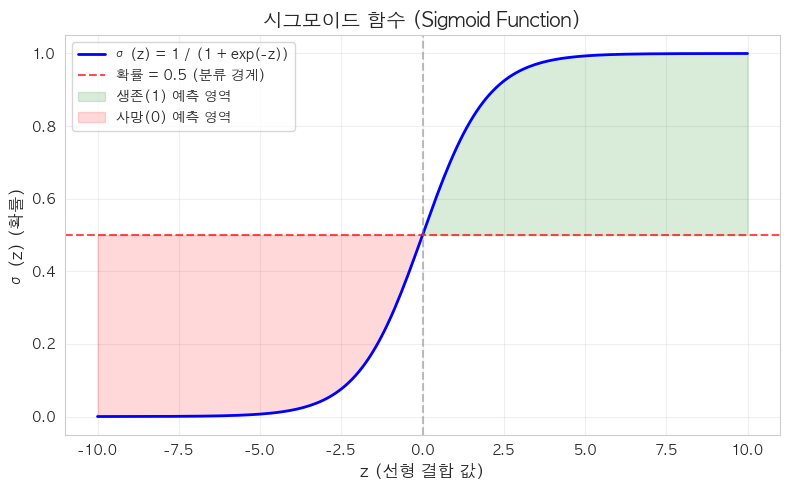

In [23]:
# 시그모이드 함수 그래프
def sigmoid(z):
    """시그모이드 함수: 입력값 z를 0~1 사이의 확률로 변환"""
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 200)

plt.figure(figsize=(8, 5))
plt.plot(z, sigmoid(z), color='blue', linewidth=2, label='σ(z) = 1 / (1 + exp(-z))')

# 기준선: 확률 0.5 (분류 경계)
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='확률 = 0.5 (분류 경계)')
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)

# 영역 표시
plt.fill_between(z, sigmoid(z), 0.5, where=(sigmoid(z) >= 0.5), alpha=0.15, color='green', label='생존(1) 예측 영역')
plt.fill_between(z, sigmoid(z), 0.5, where=(sigmoid(z) < 0.5), alpha=0.15, color='red', label='사망(0) 예측 영역')

plt.xlabel('z (선형 결합 값)', fontsize=12)
plt.ylabel('σ(z) (확률)', fontsize=12)
plt.title('시그모이드 함수 (Sigmoid Function)', fontsize=14)
plt.legend(loc='upper left', fontsize=10)
plt.ylim(-0.05, 1.05)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
from sklearn.linear_model import LogisticRegression

# 로지스틱 회귀 모델 생성 및 학습
lr = LogisticRegression(random_state=42)
lr.fit(X_train_scaled, y_train)

# 예측
y_pred = lr.predict(X_test_scaled)

# 가중치(계수) 확인
print('=== 가중치(coef) ===')
for col, coef in zip(X_train.columns, lr.coef_[0]):
    print(f'  {col:25s} = {coef:.4f}')
print(f'\n  intercept = {lr.intercept_[0]:.4f}')

=== 가중치(coef) ===
  pclass                    = -0.7853
  age                       = -0.3962
  sibsp                     = -0.3500
  parch                     = -0.0961
  fare                      = 0.1265
  sex_male                  = -1.2771
  embark_town_Queenstown    = -0.0461
  embark_town_Southampton   = -0.1894

  intercept = -0.6752


## 5. 모델 평가

### 분류 모델의 3가지 핵심 평가 도구

---

### ① accuracy_score — 전체 정확도

> "전체 문제 중에 몇 문제 맞혔나?"

```
Accuracy = 맞힌 수 / 전체 수
         = (TP + TN) / (TP + TN + FP + FN)
```

**예시:** 179명 중 145명을 맞혔으면 → 145/179 = 0.8101 (81%)

⚠️ **주의:** 데이터가 불균형하면 Accuracy만으로 판단하면 안 됩니다.
```
예: 100명 중 사망 95명, 생존 5명
    → 전부 "사망"으로 예측해도 Accuracy = 95%
    → 하지만 생존자를 한 명도 못 찾음!
    → 이런 경우 F1-Score, Recall이 더 중요
```

---

### ② classification_report — 클래스별 상세 성적표

| 지표 | 공식 | 질문 | 비유 |
|---|---|---|---|
| **Precision** | TP / (TP + FP) | "생존이라 예측한 사람 중 진짜 생존은?" | **낚시꾼의 적중률** — 잡은 물고기 중 먹을 수 있는 비율 |
| **Recall** | TP / (TP + FN) | "실제 생존자 중 몇 명을 찾아냈나?" | **경찰의 체포율** — 범인 10명 중 몇 명 잡았나 |
| **F1-Score** | 2×P×R / (P+R) | "Precision과 Recall의 균형점은?" | **종합 점수** — 둘 다 높아야 높음 |
| **Support** | - | "이 클래스는 실제로 몇 명인가?" | 해당 클래스의 실제 샘플 수 |

**출력 예시 읽는 법:**
```
              precision    recall  f1-score   support
   사망(0)       0.83      0.86      0.84       105    ← 실제 사망 105명
   생존(1)       0.79      0.74      0.76        74    ← 실제 생존 74명
```

해석:
- **사망(0) Precision=0.83**: "사망" 예측 중 83%가 진짜 사망
- **사망(0) Recall=0.86**: 실제 사망 105명 중 86%(약 90명) 정확히 찾음
- **생존(1) Recall=0.74**: 실제 생존 74명 중 74%(약 55명)만 찾음 → **19명은 놓침**
- **생존(1) F1=0.76**: 생존 예측의 종합 성적이 사망(0.84)보다 낮음

**하단 행 의미:**
```
   accuracy                           0.81       179    ← 전체 정확도 (= accuracy_score)
   macro avg       0.81      0.80      0.80       179   ← 클래스별 평균 (클래스 크기 무시)
weighted avg       0.81      0.81      0.81       179   ← 클래스 크기 비례 가중 평균
```

---

### ③ confusion_matrix — 오차(혼동) 행렬

> "어떤 클래스를 어떤 클래스로 잘못 예측했는가?" 를 보여주는 표

```
                    예측: 사망(0)     예측: 생존(1)
실제: 사망(0)          TN (90)          FP (15)      ← 실제 사망인데 생존이라 예측
실제: 생존(1)          FN (19)          TP (55)      ← 실제 생존인데 사망이라 예측
```

| 용어 | 의미 | 해석 |
|---|---|---|
| **TP (True Positive)** | 생존이라 예측 → 진짜 생존 ✅ | 맞힘 |
| **TN (True Negative)** | 사망이라 예측 → 진짜 사망 ✅ | 맞힘 |
| **FP (False Positive)** | 생존이라 예측 → 실제 사망 ❌ | **오탐 (거짓 양성)** |
| **FN (False Negative)** | 사망이라 예측 → 실제 생존 ❌ | **미탐 (거짓 음성)** |

**읽는 팁:** 대각선(TN, TP)이 크고 나머지(FP, FN)가 작을수록 좋은 모델

---

### 📝 시험 출제 포인트
- **불균형 데이터** → Accuracy 무의미 → **F1-Score** 사용
- 암 진단(놓치면 안 됨) → **Recall** 중요
- 스팸 필터(정상 메일이 차단되면 안 됨) → **Precision** 중요
- macro avg: 클래스를 동등하게 평가 / weighted avg: 샘플 수 비례

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ── ① accuracy_score ──────────────────────────────────────
# 전체 179명 중 맞힌 수 / 전체 수
# 가장 직관적이지만, 불균형 데이터에서는 주의
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')

# ── ② classification_report ──────────────────────────────
# 클래스별 Precision, Recall, F1-Score를 한 번에 출력
# target_names : 0 → '사망(0)', 1 → '생존(1)' 으로 표시
print('\n=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['사망(0)', '생존(1)']))

# 출력 읽는 법:
# precision : "생존이라 예측한 사람 중" 진짜 생존 비율
# recall    : "실제 생존자 중" 모델이 찾아낸 비율
# f1-score  : precision과 recall의 조화평균 (균형 점수)
# support   : 해당 클래스의 실제 샘플 수
# macro avg : 클래스별 평균 (클래스 크기 무시)
# weighted avg : 샘플 수 비례 가중 평균

In [ ]:
# ── ③ confusion_matrix — 오차(혼동) 행렬 시각화 ──────────
# confusion_matrix(실제값, 예측값) → 2×2 배열 반환
# [[TN, FP],
#  [FN, TP]]
# 대각선(TN, TP) = 맞힌 것 / 비대각선(FP, FN) = 틀린 것
cm = confusion_matrix(y_test, y_pred)

# 숫자로 확인
print('=== 오차(혼동) 행렬 숫자 ===')
print(f'  TN={cm[0,0]} (사망→사망✅)  FP={cm[0,1]} (사망→생존❌)')
print(f'  FN={cm[1,0]} (생존→사망❌)  TP={cm[1,1]} (생존→생존✅)')
print(f'  정확히 맞힌 수: {cm[0,0]+cm[1,1]} / {cm.sum()}')
print()

# 히트맵 시각화
fig, ax = plt.subplots(figsize=(6, 4))
# sns.heatmap 매개변수:
#   annot=True : 각 칸에 숫자 표시
#   fmt='d'    : 정수 형식
#   cmap='Blues': 파란색 계열 (숫자 클수록 진한 색)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['사망(0)', '생존(1)'],
            yticklabels=['사망(0)', '생존(1)'],
            ax=ax)
ax.set_xlabel('예측값')
ax.set_ylabel('실제값')
ax.set_title('오차(혼동) 행렬 (Confusion Matrix)')
plt.tight_layout()
plt.show()
print('→ 대각선 숫자가 클수록 좋은 모델')
print('→ FN(생존→사망 예측)이 크면: 실제 생존자를 놓침 → Recall 낮음')
print('→ FP(사망→생존 예측)이 크면: 거짓 생존 예측 많음 → Precision 낮음')